# 04 — Statistical assessment + seasonality

- Central tendency (mean, median) and dispersion (variance, std, IQR) per
  (variable, interpolation model) on the 2-deg grid.
- **Pairwise** Kolmogorov-Smirnov 2-sample test between models per variable
  (without ERA5 we compare the gridded distributions to each other).
- Seasonal climatology maps for the **best** model per variable
  (best = lowest CV RMSE from notebook 03).


In [6]:
import sys, pathlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ks_2samp

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
from utils import target_grid

GRIDS = ROOT / 'grids'
FIGS = ROOT / 'figs'; FIGS.mkdir(exist_ok=True)

lon_c, lat_c = target_grid()
VARS = ['precip', 'rh', 't_air', 't_soil', 'sm']
MODELS = ['idw', 'spherical', 'exponential', 'gaussian']


## Central tendency + dispersion

In [7]:
rows = []
for var in VARS:
    g = xr.open_dataset(GRIDS / f'uscrn_grid_2deg_{var}.nc')[var]
    for m in MODELS:
        x = g.sel(model=m).values.ravel()
        x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        rows.append({
            'variable': var, 'model': m, 'n': int(x.size),
            'mean':   float(np.mean(x)),
            'median': float(np.median(x)),
            'var':    float(np.var(x)),
            'std':    float(np.std(x)),
            'iqr':    float(np.subtract(*np.percentile(x, [75, 25]))),
        })

stats = pd.DataFrame(rows)
stats.to_csv(FIGS / 'central_dispersion.csv', index=False)
stats


,variable,model,n,mean,median,var,std,iqr
0,precip,idw,142740,2.506119,1.060524,1.913119e+01,4.373921,2.451039
1,precip,spherical,142740,2.732391,1.548724,1.915067e+01,4.376147,3.045331
2,precip,exponential,142740,2.737994,1.392552,2.075940e+01,4.556249,2.979568
3,precip,gaussian,142740,-3.534787,1.666867,4.601405e+05,678.336548,3.548791
4,rh,idw,142740,63.289780,65.974854,2.175631e+02,14.750022,20.809890
5,rh,spherical,142740,65.481522,69.191742,3.260479e+02,18.056795,23.974556
6,rh,exponential,142740,65.488022,69.523605,3.271273e+02,18.086660,24.029022
7,rh,gaussian,142740,64.747498,68.176033,3.732594e+02,19.319921,24.475986
8,t_air,idw,142740,286.328033,286.783569,8.103486e+01,9.001936,14.751480
9,t_air,spherical,142740,286.793396,288.051056,1.014753e+02,10.073493,15.078339


## Pairwise KS two-sample test

For each variable, run the KS-2sample between every pair of models on the
gridded daily values. Small D and large p-value -> distributions are similar.


In [8]:
rng = np.random.default_rng(0)
ks_rows = []
for var in VARS:
    g = xr.open_dataset(GRIDS / f'uscrn_grid_2deg_{var}.nc')[var]
    samples = {}
    for m in MODELS:
        x = g.sel(model=m).values.ravel(); x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        n = min(x.size, 50_000)
        samples[m] = rng.choice(x, n, replace=False)
    for a, b in combinations(samples.keys(), 2):
        D, p = ks_2samp(samples[a], samples[b])
        ks_rows.append({'variable': var, 'model_a': a, 'model_b': b,
                        'ks_D': float(D), 'p_value': float(p)})

ks = pd.DataFrame(ks_rows)
ks.to_csv(FIGS / 'ks_pairwise.csv', index=False)
ks


,variable,model_a,model_b,ks_D,p_value
0,precip,idw,spherical,0.13702,0.000000e+00
1,precip,idw,exponential,0.10294,4.217515e-231
2,precip,idw,gaussian,0.19286,0.000000e+00
3,precip,spherical,exponential,0.05014,4.626001e-55
4,precip,spherical,gaussian,0.11354,3.398791e-281
5,precip,exponential,gaussian,0.14736,0.000000e+00
6,rh,idw,spherical,0.13160,0.000000e+00
7,rh,idw,exponential,0.13200,0.000000e+00
8,rh,idw,gaussian,0.10972,1.430148e-262
9,rh,spherical,exponential,0.01082,5.697165e-03


## Seasonal climatology (best model per variable)

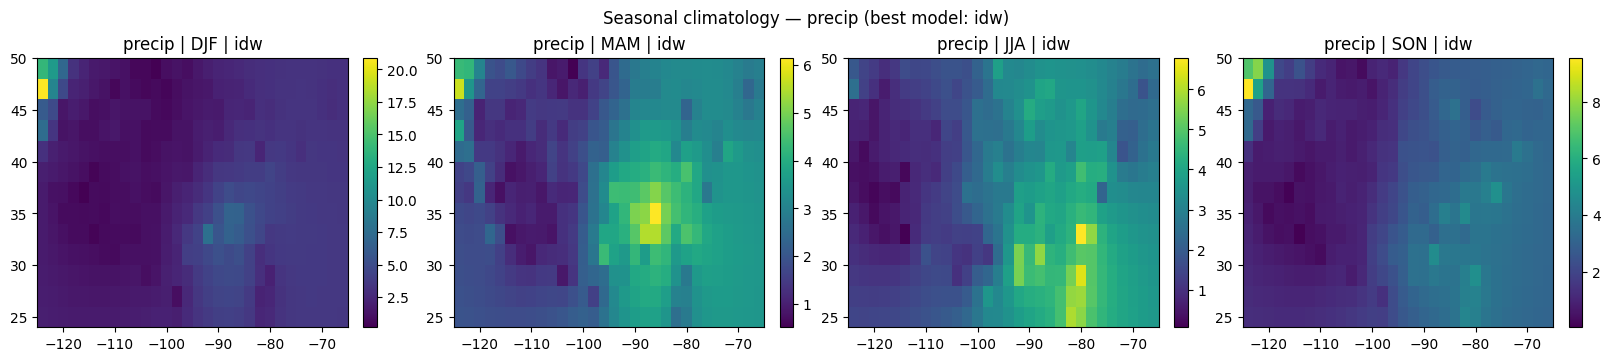

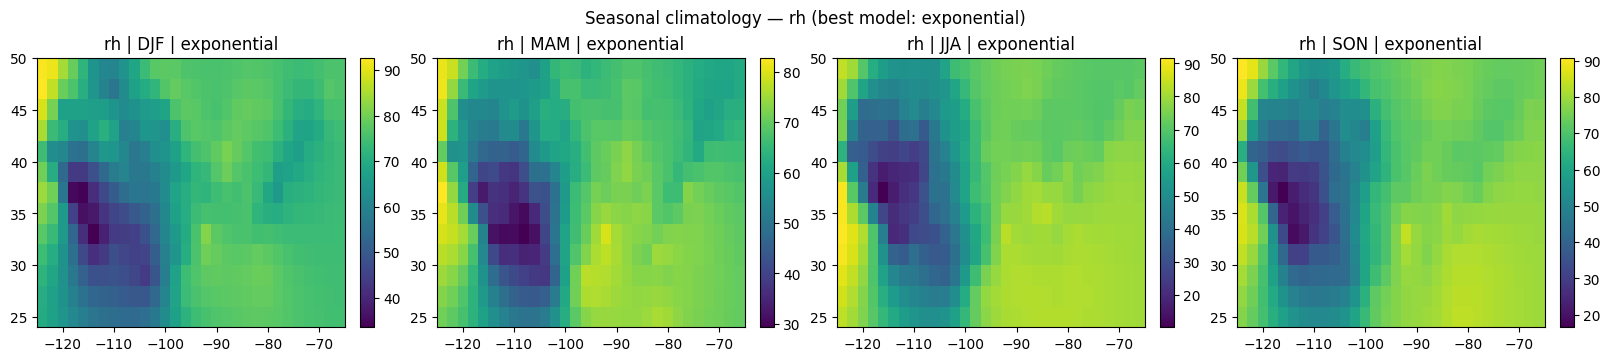

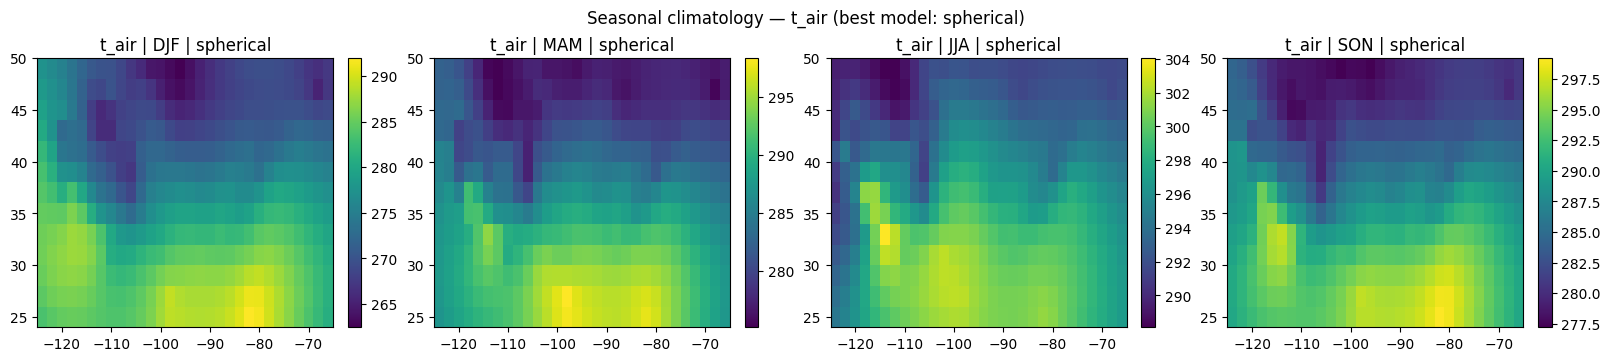

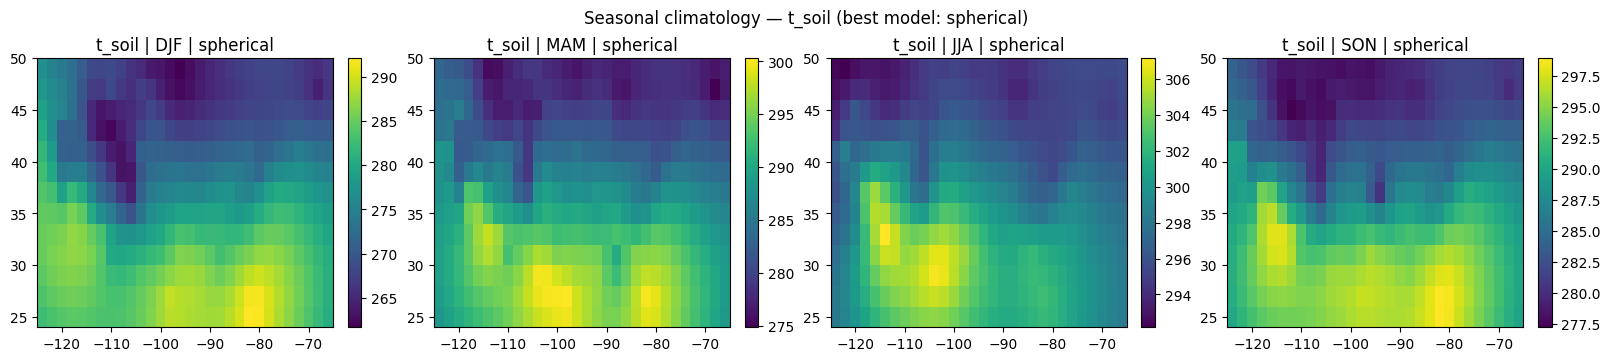

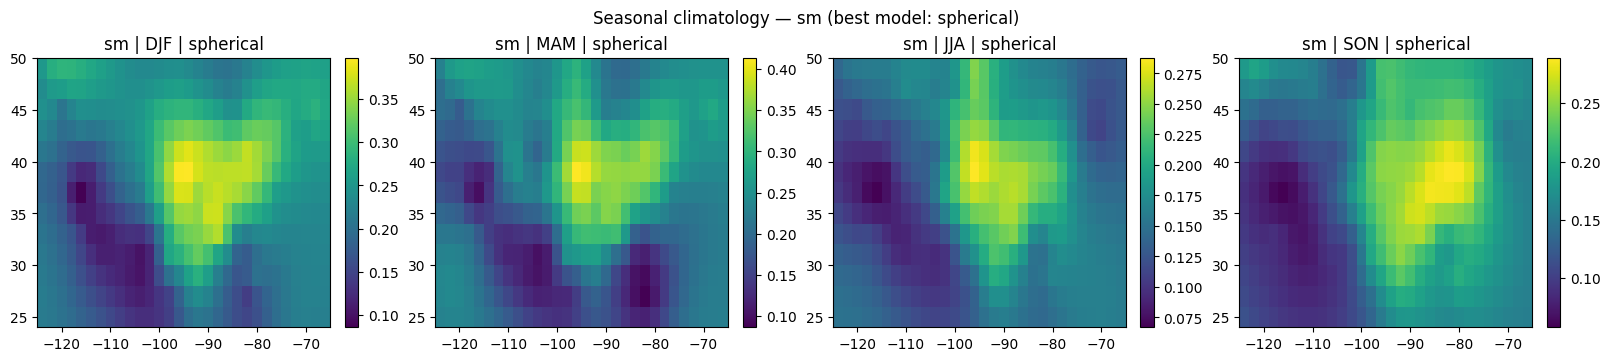

In [9]:
best = pd.read_csv(FIGS / 'best_model_per_variable.csv').set_index('variable')['model'].to_dict()
SEASONS = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}

for var in VARS:
    m = best.get(var, 'spherical')
    g = xr.open_dataset(GRIDS / f'uscrn_grid_2deg_{var}.nc')[var].sel(model=m)
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), constrained_layout=True)
    for ax, (label, months) in zip(axes, SEASONS.items()):
        season_mean = g.where(g['time.month'].isin(months)).mean('time')
        im = ax.pcolormesh(lon_c, lat_c, season_mean, shading='auto')
        ax.set_title(f'{var} | {label} | {m}')
        plt.colorbar(im, ax=ax)
    fig.suptitle(f'Seasonal climatology — {var} (best model: {m})')
    fig.savefig(FIGS / f'seasonal_{var}.png', dpi=120)
    plt.show()


## Recommended interpolation model per variable

In [10]:
print(pd.read_csv(FIGS / 'best_model_per_variable.csv').to_string(index=False))


variable       model      n      rmse  pearson_r
  precip         idw 9470.0  6.747540   0.641104
      rh exponential 8388.0 11.224584   0.853325
      sm   spherical 7114.0  0.088457   0.657695
   t_air   spherical 9515.0  2.943704   0.959880
  t_soil   spherical 8414.0  3.982847   0.943256
